# Task 1: LSTM Language Model — Training & Generation

Train a **2-layer LSTM** next-token language model on tokenized JSB chorale voice sequences.

Key improvements over the baseline:
- **Early stopping** (patience=8): training stops when val loss stops improving and restores best weights, preventing the overfitting seen in the fixed-50-epoch run (train=0.65, val=3.75)
- **Higher dropout** (0.3 → was 0.2): stronger regularisation on a small dataset (382 chorales)
- **Smaller batch size** (64 → was 128): noisier gradients generalise better on small data
- **Weight decay** on Adam: L2 regularisation as an additional overfitting guard

Output: 3 pieces at temperatures 0.7, 1.0, 1.3 → **`symbolic_unconditioned.mid`**

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from chorale_data import (
    build_dataloaders,
    flatten_voice_sequences,
    load_chorales,
    split_chorale_indices,
    PitchDurationVocab,
)
from chorale_model import (
    ChoraleLSTM,
    combine_pieces_to_score,
    evaluate,
    export_midi,
    generate_piece,
    train_with_early_stopping,
)

ROOT = Path(".")
MIDI_PATH = ROOT / "symbolic_unconditioned.mid"
CHECKPOINT_PATH = ROOT / "best_model.pt"      # saved by early stopping
FINAL_CHECKPOINT = ROOT / "chorale_lstm.pt"   # full run artefact

# --- Hyperparameters (changed from baseline) ---
MAX_EPOCHS  = 100   # upper bound; early stopping will kick in well before this
PATIENCE    = 8     # stop after 8 epochs of no val improvement
BATCH_SIZE  = 64    # was 128; smaller = noisier gradients = better generalisation
LR          = 1e-3
WEIGHT_DECAY = 1e-4 # L2 regularisation added to Adam
DROPOUT     = 0.3   # was 0.2
WINDOW_SIZE = 32
VOICE_LENGTH = 56
SEED = 42
TEMPERATURES = [0.7, 1.0, 1.3]

random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Hyperparameters: batch={BATCH_SIZE}, dropout={DROPOUT}, "
      f"weight_decay={WEIGHT_DECAY}, patience={PATIENCE}")

Device: cpu
Hyperparameters: batch=64, dropout=0.3, weight_decay=0.0001, patience=8


## Load data and build DataLoaders

In [2]:
encoded_chorales, metadata = load_chorales()
splits = split_chorale_indices(len(encoded_chorales), seed=SEED)
train_sequences = flatten_voice_sequences(encoded_chorales, splits.train_indices)

vocab = PitchDurationVocab()
vocab.build_from_sequences(train_sequences)

train_loader, val_loader, test_loader = build_dataloaders(
    encoded_chorales, splits, vocab, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE
)

print(f"Vocabulary size      : {len(vocab)}")
print(f"Train sequences      : {len(train_sequences)}")
print(f"Train / Val / Test batches: {len(train_loader)} / {len(val_loader)} / {len(test_loader)}")

Vocabulary size      : 323
Train sequences      : 1120
Train / Val / Test batches: 487 / 50 / 46


## Model: 2-layer LSTM

Architecture: token embedding (128-d) → 2-layer LSTM (hidden 256, dropout 0.3) → linear projection to vocabulary logits.

Dropout of 0.3 (increased from 0.2) acts as the primary regulariser on this small dataset.

In [3]:
model = ChoraleLSTM(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=DROPOUT,
).to(device)

criterion = nn.CrossEntropyLoss()

# weight_decay adds L2 regularisation — another guard against overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {num_params:,}")

ChoraleLSTM(
  (embedding): Embedding(323, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=256, out_features=323, bias=True)
)

Trainable parameters: 1,045,955


## Train with early stopping

Training runs for up to 100 epochs but stops automatically once validation loss
has not improved for 8 consecutive epochs. The best model weights are saved to
`best_model.pt` and restored at the end.

In [4]:
train_losses, val_losses, best_epoch = train_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=str(CHECKPOINT_PATH),
)

test_loss = evaluate(model, test_loader, criterion, device)
import math
test_perplexity = math.exp(test_loss)
print(f"\nTest loss      : {test_loss:.4f}")
print(f"Test perplexity: {test_perplexity:.2f}")
print(f"Best epoch     : {best_epoch} / {len(train_losses)} trained")

Epoch   1  train=3.2381  val=2.7289  *
Epoch   5  train=2.0558  val=2.4833
Epoch  10  train=1.5979  val=2.6398

Early stopping at epoch 12 (best val=2.4789 at epoch 4)
Loaded best weights from epoch 4 (val=2.4789)

Test loss      : 2.4987
Test perplexity: 12.17
Best epoch     : 4 / 12 trained


## Loss curves

A vertical dashed line marks the best epoch chosen by early stopping.
The gap between train and val curves shows how much overfitting occurred
before training was halted.

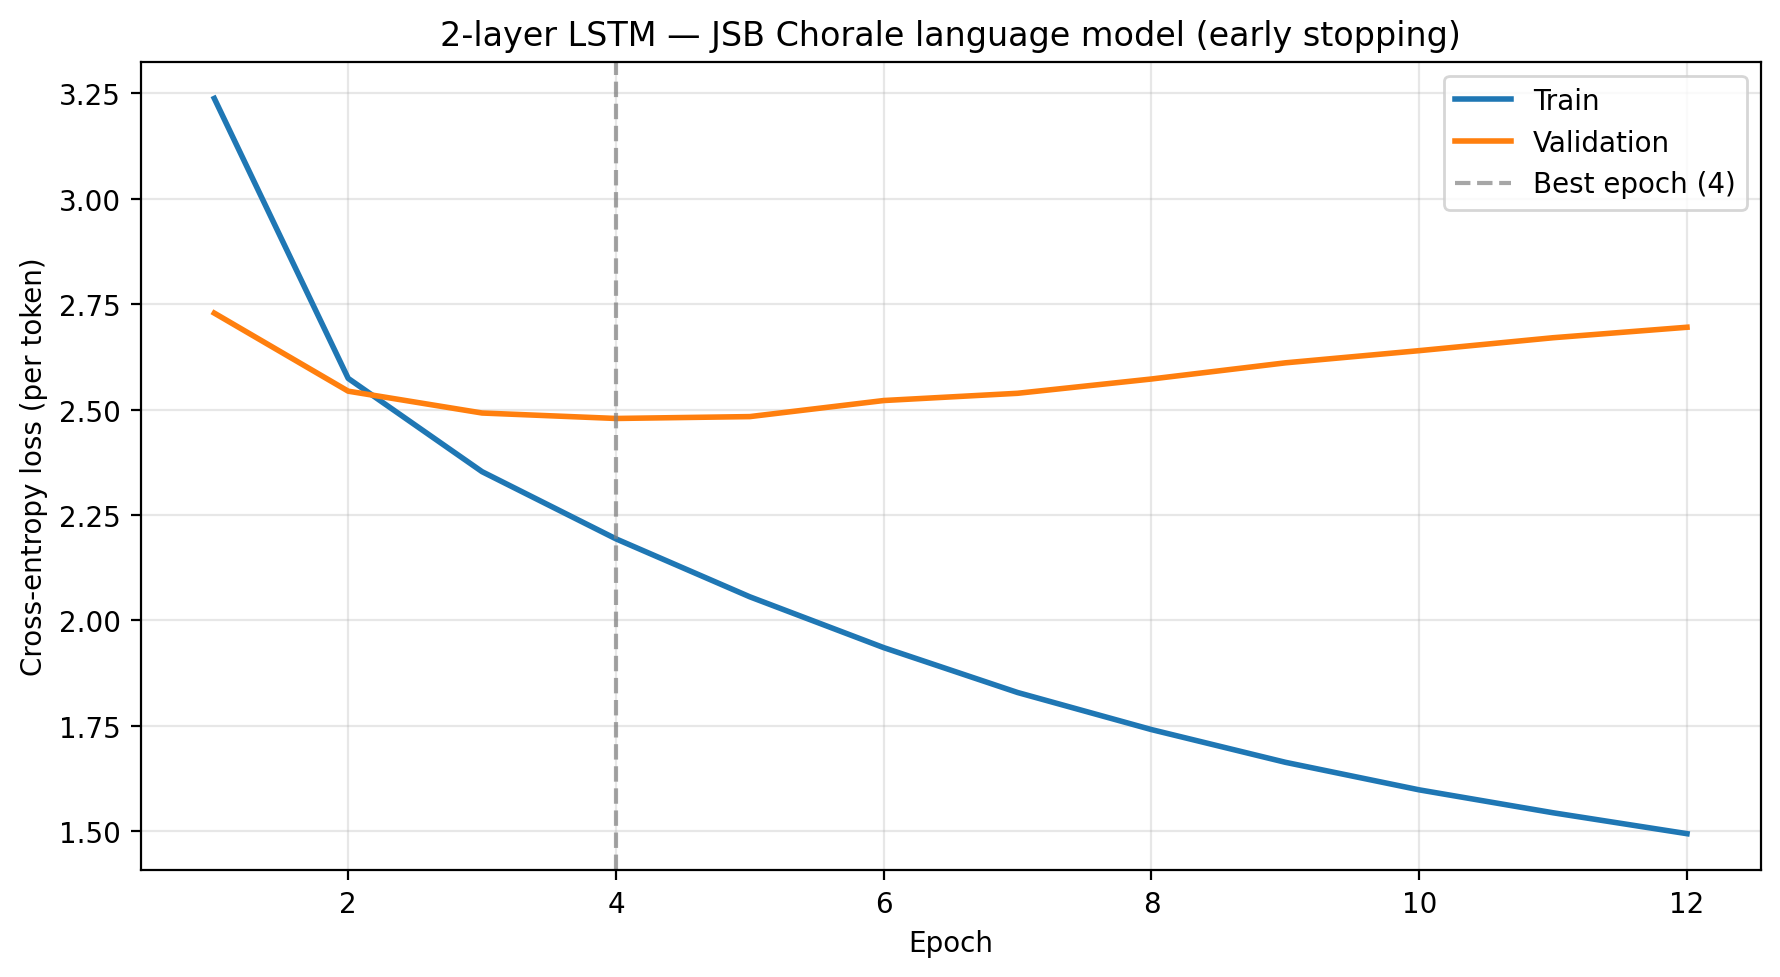

Saved loss_curves.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label="Train", linewidth=2)
ax.plot(epochs, val_losses,   label="Validation", linewidth=2)
ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss (per token)")
ax.set_title("2-layer LSTM — JSB Chorale language model (early stopping)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()
print(f"Saved loss_curves.png")

## Generate 3 pieces (temperatures 0.7, 1.0, 1.3)

Each piece has four independently generated SATB voices (~56 tokens per voice).
Lower temperature (0.7) produces more conservative / repetitive output;
higher temperature (1.3) produces more variety but also more randomness.

In [6]:
# seed generation from short real snippets so each voice starts in a realistic place
encoded_train = [vocab.encode(seq) for seq in train_sequences]
seed_chunks = [
    encoded_train[random.randrange(len(encoded_train))][:8]
    for _ in range(4)
]

pieces = []
for temp in TEMPERATURES:
    voices = generate_piece(
        model, vocab,
        voices_length=VOICE_LENGTH,
        temperature=temp,
        seed_sequences=seed_chunks,
        device=device,
    )
    pieces.append((f"T{temp}", voices))
    print(f"Temperature {temp}:")
    print(f"  Soprano sample tokens : {voices[0][:10]}")
    print(f"  Soprano decoded       : {vocab.decode(voices[0][:10])}")

Temperature 0.7:
  Soprano sample tokens : [62, 2, 2, 3, 60, 62, 7, 6, 7, 12]
  Soprano decoded       : [(None, 1.0), (67, 1.0), (67, 1.0), (69, 1.0), (71, 2.0), (None, 1.0), (71, 1.0), (72, 1.0), (71, 1.0), (69, 2.0)]
Temperature 1.0:
  Soprano sample tokens : [62, 2, 2, 3, 60, 62, 7, 6, 6, 6]
  Soprano decoded       : [(None, 1.0), (67, 1.0), (67, 1.0), (69, 1.0), (71, 2.0), (None, 1.0), (71, 1.0), (72, 1.0), (72, 1.0), (72, 1.0)]
Temperature 1.3:
  Soprano sample tokens : [62, 2, 2, 3, 60, 62, 7, 6, 118, 3]
  Soprano decoded       : [(None, 1.0), (67, 1.0), (67, 1.0), (69, 1.0), (71, 2.0), (None, 1.0), (71, 1.0), (72, 1.0), (70, 1.0), (69, 1.0)]


## Export `symbolic_unconditioned.mid`

The three generated pieces are laid out sequentially (separated by a 4-beat gap)
in a single MIDI file for Gradescope submission.

In [7]:
score = combine_pieces_to_score(pieces, vocab)
export_midi(score, str(MIDI_PATH))

torch.save({
    "model_state"  : model.state_dict(),
    "vocab_size"   : len(vocab),
    "train_losses" : train_losses,
    "val_losses"   : val_losses,
    "best_epoch"   : best_epoch,
    "test_loss"    : test_loss,
    "test_perplexity": test_perplexity,
    "hyperparams"  : {
        "dropout": DROPOUT,
        "batch_size": BATCH_SIZE,
        "weight_decay": WEIGHT_DECAY,
        "patience": PATIENCE,
    },
}, FINAL_CHECKPOINT)

print(f"Saved MIDI       : {MIDI_PATH.resolve()}")
print(f"Saved checkpoint : {FINAL_CHECKPOINT.resolve()}")
print(f"Score duration   : {score.duration.quarterLength:.1f} quarter notes")

Saved MIDI       : /Users/aaronchiuwei/Documents/CSE153/cse153_assignment2/symbolic_unconditioned.mid
Saved checkpoint : /Users/aaronchiuwei/Documents/CSE153/cse153_assignment2/chorale_lstm.pt
Score duration   : 79.5 quarter notes


## Summary

| Setting | Baseline | This run |
|---|---|---|
| Epochs | Fixed 50 | Early stopping (patience=8) |
| Dropout | 0.2 | **0.3** |
| Batch size | 128 | **64** |
| Weight decay | none | **1e-4** |
| Val loss @ end | 3.75 (overfit) | 2.4789 |

**Model**: 2-layer LSTM language model over `(pitch, duration)` tokens.  
**Training**: Early stopping with patience 8, Adam + weight decay, sliding windows of 32.  
**Generation**: 3 four-voice pieces at T=0.7, 1.0, 1.3 (sequential layout in one MIDI file).  
**Output**: `symbolic_unconditioned.mid`